In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# What columns do we have?
print(df.columns.tolist())

# Data types
print(df.dtypes)

# Any nulls?
print(df.isnull().sum())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner 

In [3]:
# TotalCharges has a known issue — stored as string, not float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many rows got nulled
print("Nulls in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# These are new customers with 0 tenure — safe to fill with 0
df['TotalCharges'].fillna(0, inplace=True)

print("TotalCharges dtype now:", df['TotalCharges'].dtype)
print("Done! Data is clean.")

Nulls in TotalCharges after conversion: 11
TotalCharges dtype now: float64
Done! Data is clean.


## Data Quality Finding #1
- Found 11 records with blank TotalCharges
- All were new customers with tenure = 0
- Filled with 0 — business logic: no charges yet for brand new customers
- TotalCharges converted from string to float64 for numeric analysis

Churn
No     5174
Yes    1869
Name: count, dtype: int64
---
Churn
No     0.73
Yes    0.27
Name: proportion, dtype: float64


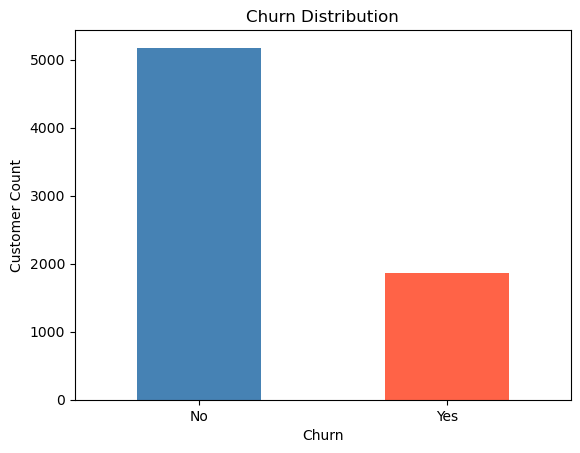

In [4]:
# How many churned vs stayed?
print(df['Churn'].value_counts())
print("---")
print(df['Churn'].value_counts(normalize=True).round(2))

# Visualize it
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Churn Distribution')
plt.ylabel('Customer Count')
plt.xticks(rotation=0)
plt.show()

=== Churn Rate by Contract Type ===
Churn             No   Yes
Contract                  
Month-to-month  0.57  0.43
One year        0.89  0.11
Two year        0.97  0.03

=== Churn Rate by Internet Service ===
Churn              No   Yes
InternetService            
DSL              0.81  0.19
Fiber optic      0.58  0.42
No               0.93  0.07

=== Tenure Distribution ===


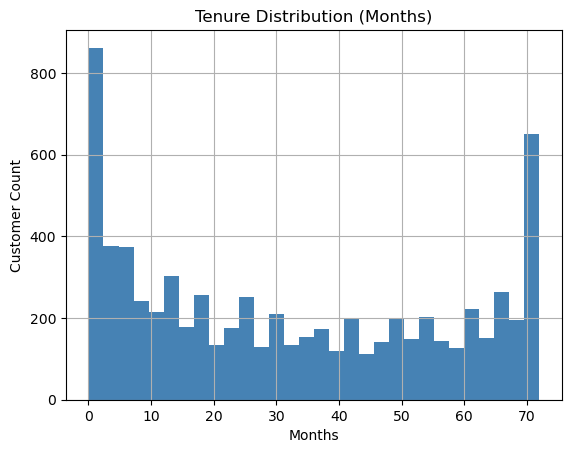

In [5]:
# Churn rate by Contract type
print("=== Churn Rate by Contract Type ===")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().round(2))

print("\n=== Churn Rate by Internet Service ===")
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack().round(2))

print("\n=== Tenure Distribution ===")
df['tenure'].hist(bins=30, color='steelblue')
plt.title('Tenure Distribution (Months)')
plt.xlabel('Months')
plt.ylabel('Customer Count')
plt.show()

## Key Finding #2 — Who is Churning?

**Contract Type:**
- Month-to-month: 43% churn rate (HIGHEST RISK)
- One year: 11% churn rate
- Two year: 3% churn rate (MOST LOYAL)

**Internet Service:**
- Fiber optic: 42% churn rate (HIGH RISK)
- DSL: 19% churn rate
- No internet: 7% churn rate

**Tenure:**
- Highest churn in first 1-2 months (new customer drop-off)
- Customers past Month 12 show significantly better retention

**Business Implication:**
- Priority retention target: Month-to-month + Fiber optic customers
- Early intervention needed in first 90 days of customer lifecycle